In [10]:
# from google.colab import drive
# drive.mount('/content/drive')

In [11]:
import os
DRIVE_DIRECTORY = "../10-Redes_neurais_artificiais/exercicios/novo/"
#DRIVE_DIRECTORY = os.path.join("/content/drive/MyDrive", DRIVE_DIRECTORY)

comando no linux 

find -name 'cov_type*'
    
./Fabiene/UDEMY_ML/Machine_Learning_Udemy/10-Redes_neurais_artificiais/exercicios/novo/cov_types.csv


ambiente anaconda orange3

In [12]:
#!pip install plotly

In [13]:
import numpy as np
import pandas as pd
import pickle
import plotly.express as px

from pyod.models.knn import KNN

## Detecção de outliers

Mais uma vez, recupere o arquivo `cov_types.csv` com os dados da base de cobertura vegetal.

In [14]:
base = pd.read_csv(os.path.join(DRIVE_DIRECTORY, 'cov_types.csv'))

In [15]:
base.tail(20)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type
9980,3182.0,319.0,4.0,309.0,43.0,4685.0,208.0,235.0,166.0,2420.0,0,28,Lodgepole Pine
9981,3130.0,0.0,6.0,277.0,18.0,3750.0,212.0,229.0,155.0,1371.0,0,28,Spruce/Fir
9982,2988.0,324.0,6.0,342.0,23.0,4956.0,205.0,233.0,168.0,5544.0,0,11,Lodgepole Pine
9983,2374.0,311.0,18.0,124.0,32.0,1489.0,169.0,225.0,195.0,421.0,3,9,Douglas-fir
9984,3275.0,142.0,16.0,201.0,18.0,3045.0,241.0,235.0,118.0,841.0,0,22,Spruce/Fir
9985,3246.0,309.0,15.0,430.0,119.0,3578.0,177.0,229.0,192.0,1894.0,2,30,Spruce/Fir
9986,3199.0,293.0,12.0,466.0,81.0,876.0,185.0,237.0,192.0,700.0,2,22,Lodgepole Pine
9987,3388.0,94.0,12.0,607.0,155.0,1848.0,239.0,221.0,110.0,1790.0,0,34,Krummholz
9988,3210.0,43.0,8.0,0.0,0.0,124.0,222.0,223.0,136.0,830.0,1,15,Lodgepole Pine
9989,3317.0,63.0,10.0,30.0,-2.0,2873.0,229.0,221.0,124.0,1806.0,2,37,Krummholz


### Crie boxplots para as 3 primeiras variáveis.

In [16]:
fig = px.box(base["Elevation"])
fig.show()

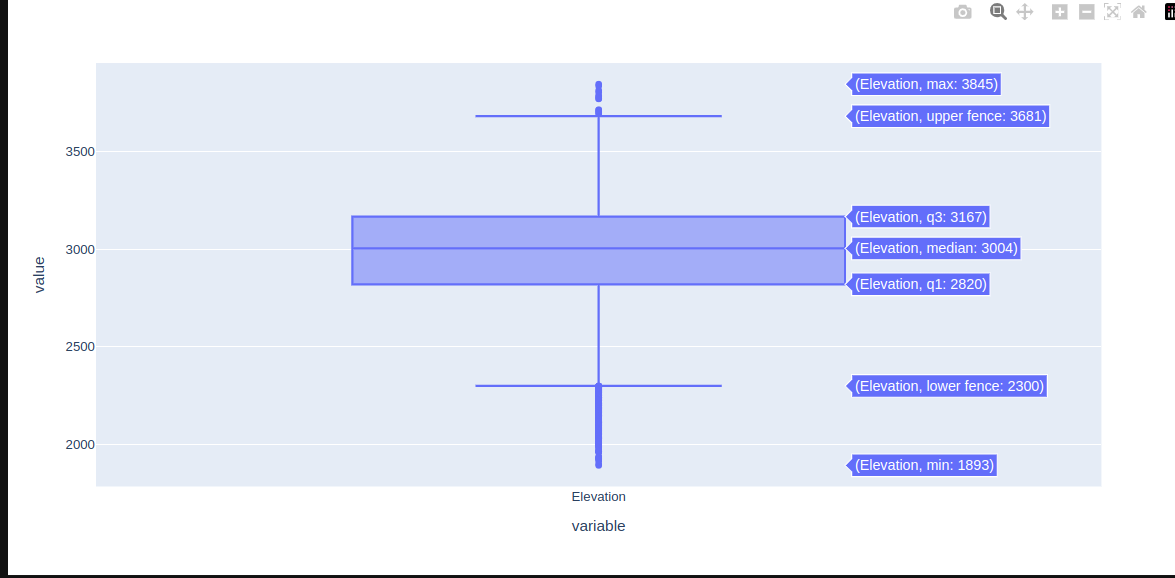

In [17]:
import plotly.express as px

# Usando o DataFrame e nome da coluna
fig = px.box(base, y="Elevation", title="Distribuição de Elevation")
fig.show()

In [18]:
import plotly.io as pio

# Isso força o gráfico a abrir em uma nova aba do navegador ou no notebook
pio.renderers.default = 'notebook_connected' # ou use 'browser' para abrir fora do notebook

fig = px.box(base, y="Elevation")
fig.show()

In [19]:
fig = px.box(base["Aspect"])
fig.show()

# sem outlier 
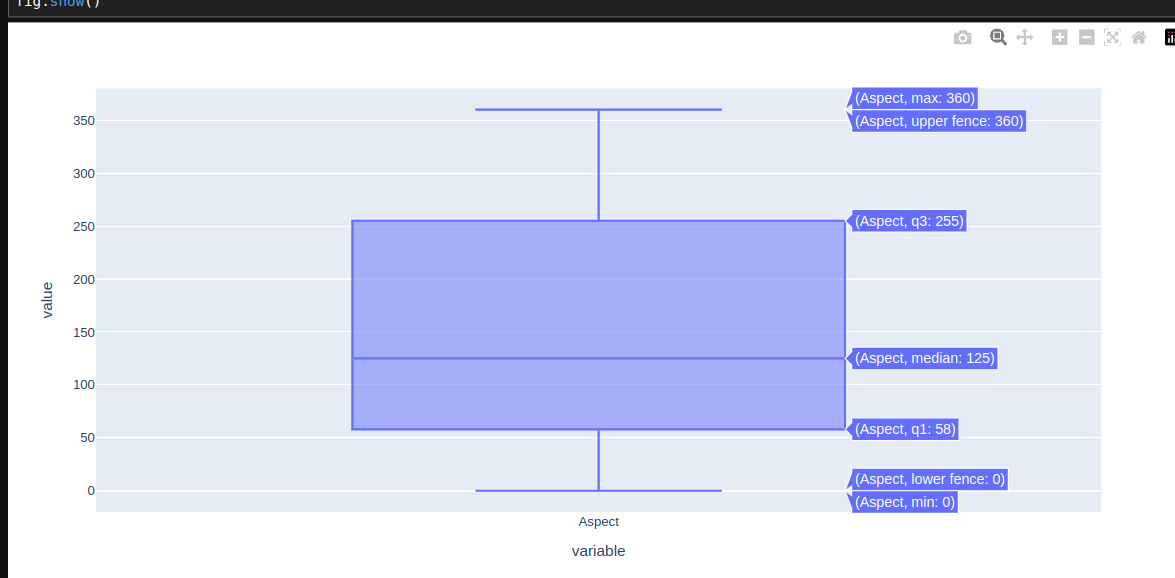

In [20]:
# Usando o DataFrame e nome da coluna
fig = px.box(base, y="Slope", title="Distribuição de Slope")
fig.show()

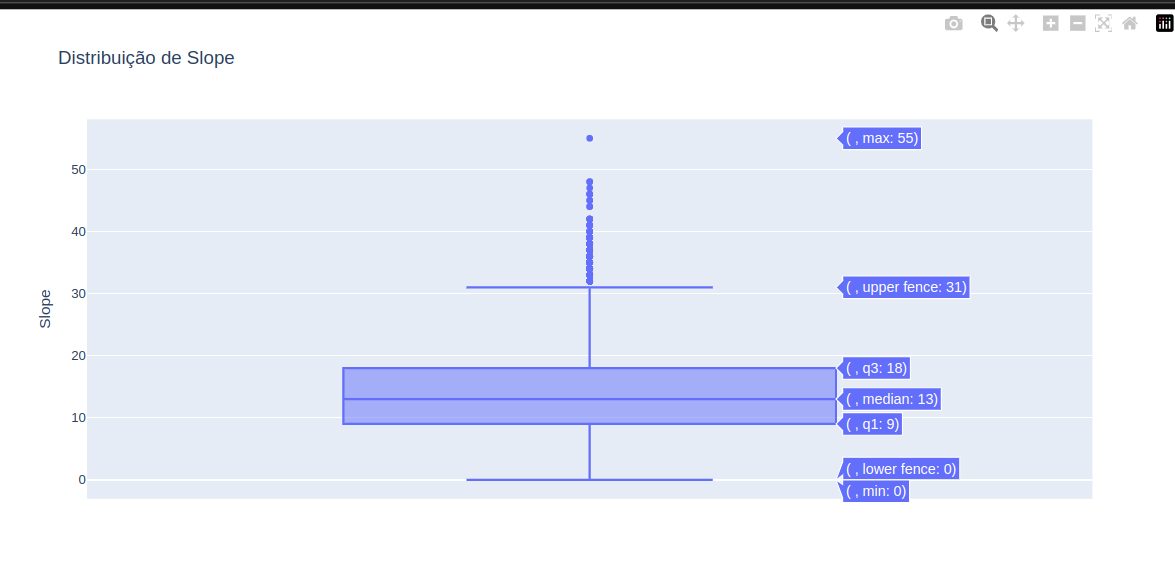

# Crie scatterplots com a combinação das 3 primeiras variáveis. =>  o que estiver fora da concentração é outlier

In [21]:
fig = px.scatter(x=base["Elevation"], y=base["Aspect"])
fig.show()

In [22]:
fig = px.scatter(
    x=base["Elevation"], 
    y=base["Aspect"],
    labels={"x": "Elevação (m)", "y": "Aspecto (Graus)"}, # define os nomes
    title="Relação entre Elevação e Aspecto"
)
fig.show()

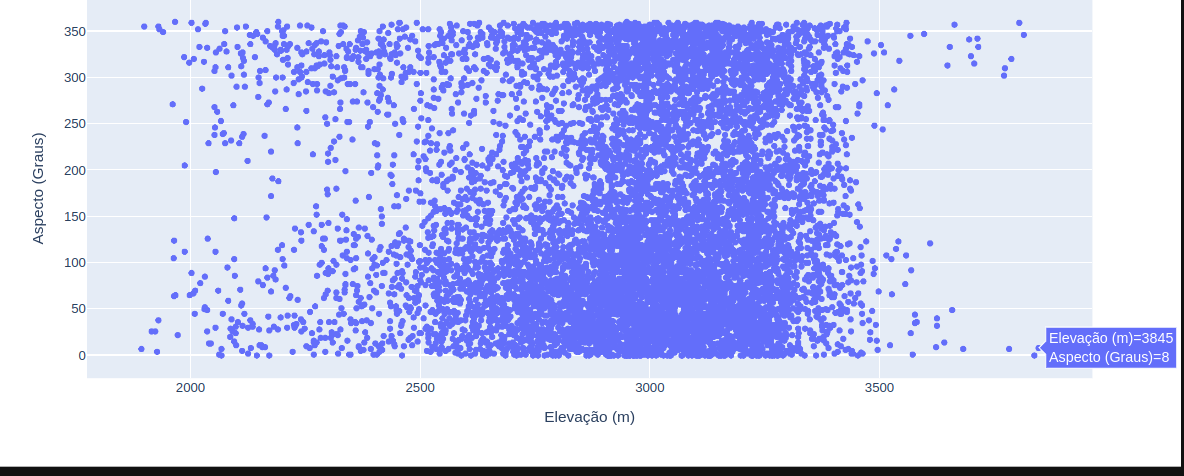

In [23]:
# fig = px.scatter(x=base["Elevation"], y=base["Slope"])
# fig.show()

fig = px.scatter(
    x=base["Elevation"], 
    y=base["Slope"],
    labels={"x": "Elevação (m)", "y": "Slope"}, # define os nomes
    title="Relação entre Elevação e Slope"
)
fig.show()

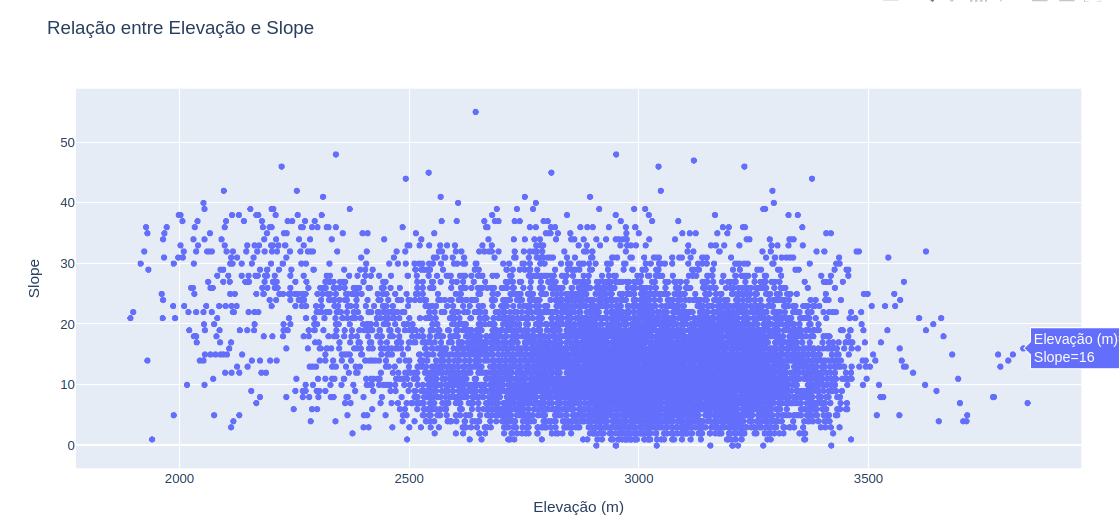

In [24]:
# fig = px.scatter(x=base["Aspect"], y=base["Slope"])
# fig.show()

fig = px.scatter(
    x=base["Aspect"], 
    y=base["Slope"],
    labels={"x": "Aspect ", "y": "Slope"}, # define os nomes
    title="Relação entre Aspect e Slope"
)
fig.show()

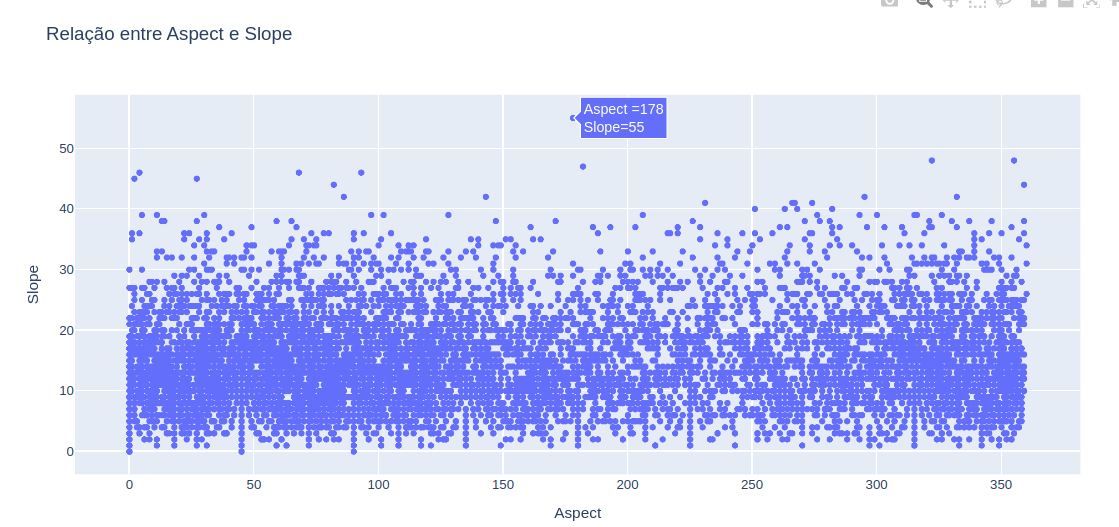

In [25]:
base.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type',
       'Cover_Type'],
      dtype='object')

Crie um detector de outliers do tipo `KNN`, e passe os dados para o método `fit`. Passe somente as variáveis preditoras numéricas. Você pode selecionar variáveis em sequência com a construção `dataframe.loc[:, "var_1":"var_n"]`.

In [30]:
base.head(2)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type
0,2767.0,66.0,17.0,210.0,18.0,1190.0,234.0,204.0,96.0,2251.0,2,30,Lodgepole Pine
1,2724.0,160.0,19.0,60.0,4.0,1350.0,236.0,240.0,127.0,2514.0,2,16,Lodgepole Pine


In [28]:
detector = KNN()
detector.fit(base.loc[:, "Elevation":"Horizontal_Distance_To_Fire_Points"]) 

# coletar as colunas da Elevation até Horizontal_Distance_To_Fire_Points

,contamination,0.1
,n_neighbors,5
,method,'largest'
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,1


In [29]:
detector.get_params()

{'algorithm': 'auto',
 'contamination': 0.1,
 'leaf_size': 30,
 'method': 'largest',
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': 1,
 'n_neighbors': 5,
 'p': 2,
 'radius': 1.0}

# verificar os rótulos labels e as frequências

Recupere e exiba os rótulos, e depois sua frequência.

In [31]:
labels = detector.labels_
labels

array([0, 0, 0, ..., 0, 0, 0])

In [32]:
np.unique(labels, return_counts=True)

(array([0, 1]), array([9000, 1000]))

### Recupere e exiba também os scores de decisão.

In [33]:
confidence = detector.decision_scores_
confidence

array([128.35108102, 162.95091285, 218.40329668, ..., 135.57285864,
       193.45542122, 160.15617378])

### Recupere os índices dos outliers. Utilize a função `np.where` para isso. Lembre-se que esta função retorna uma tupla com um único elemento, então recupere este elemento através do índice `0`.

In [34]:
# recuperar o item indicies outliers que é igual a 1
indices_outliers = np.where(labels == 1)[0]
indices_outliers

array([  11,   13,   44,   48,   50,   71,   83,   93,   95,   99,  100,
        104,  108,  115,  118,  119,  136,  142,  155,  156,  162,  190,
        209,  210,  211,  220,  238,  247,  255,  258,  260,  265,  275,
        337,  340,  346,  361,  393,  400,  429,  430,  432,  441,  445,
        463,  464,  467,  482,  483,  498,  515,  546,  554,  556,  561,
        575,  602,  620,  621,  623,  628,  640,  645,  648,  666,  671,
        681,  685,  719,  733,  753,  756,  766,  772,  781,  787,  791,
        798,  807,  810,  818,  821,  840,  845,  861,  865,  871,  888,
        891,  913,  917,  931,  932,  934,  951,  959,  978,  991,  997,
       1000, 1002, 1007, 1009, 1035, 1043, 1061, 1065, 1073, 1079, 1080,
       1084, 1089, 1101, 1105, 1109, 1111, 1114, 1124, 1137, 1144, 1148,
       1161, 1162, 1177, 1182, 1191, 1194, 1196, 1199, 1200, 1202, 1209,
       1214, 1228, 1247, 1249, 1251, 1261, 1281, 1285, 1286, 1307, 1358,
       1363, 1369, 1370, 1373, 1389, 1394, 1402, 14

In [35]:
base_outliers = base.iloc[indices_outliers, :]
base_outliers

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type
11,2957.0,43.0,11.0,664.0,194.0,1615.0,222.0,215.0,126.0,1958.0,2,32,Lodgepole Pine
13,2533.0,13.0,9.0,0.0,0.0,484.0,211.0,221.0,146.0,2095.0,0,19,Lodgepole Pine
44,3215.0,281.0,20.0,210.0,61.0,4606.0,162.0,238.0,213.0,3424.0,0,28,Spruce/Fir
48,3201.0,199.0,17.0,750.0,117.0,404.0,212.0,252.0,170.0,2469.0,2,22,Lodgepole Pine
50,2832.0,335.0,28.0,285.0,126.0,2964.0,147.0,191.0,176.0,1775.0,0,28,Lodgepole Pine
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9947,3159.0,320.0,15.0,987.0,-43.0,1385.0,181.0,225.0,183.0,1148.0,2,30,Spruce/Fir
9977,3155.0,333.0,7.0,30.0,3.0,3464.0,203.0,230.0,166.0,4842.0,0,18,Spruce/Fir
9982,2988.0,324.0,6.0,342.0,23.0,4956.0,205.0,233.0,168.0,5544.0,0,11,Lodgepole Pine
9988,3210.0,43.0,8.0,0.0,0.0,124.0,222.0,223.0,136.0,830.0,1,15,Lodgepole Pine


In [37]:
print(f'Foram identificados {len(base_outliers)} quantidades de outliers.')

Foram identificados 1000 quantidades de outliers.
